# 6. Selección de Variables Multi-Versión

Este notebook calcula importancia de variables para **cada versión de target** creada en el notebook 5.

## Enfoque
- Usa datasets mergeados `data/merged_versions/OPERA_COMPLETO_*.xlsx`
- Aplica filtro de adultos (`Edad >= 18`)
- Calcula ranking con **Mutual Information** + **Random Forest Importance**
- Exporta ranking y selección por versión para modelado comparativo

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import warnings

import sys
from pathlib import Path

project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from utils.multi_version import run_feature_selection_pipeline
from utils.version_config import ACTIVE_VERSIONS, VERSION_HISTORY

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42
TOP_N = 80

DATA_DIR = Path("../data")
MERGED_DIR = DATA_DIR / "merged_versions"
FEATURES_DIR = Path("../features")
VERSION_FEATURES_DIR = FEATURES_DIR / "versioned"
VERSION_FEATURES_DIR.mkdir(parents=True, exist_ok=True)

## 2. Carga de Versiones y Metadatos

In [2]:
print(f"Versiones activas: {ACTIVE_VERSIONS}")
display(pd.DataFrame(VERSION_HISTORY))

selection_artifacts = run_feature_selection_pipeline(
    merged_dir=MERGED_DIR,
    output_dir=VERSION_FEATURES_DIR,
    top_n=TOP_N,
    random_state=RANDOM_STATE,
    active_versions=ACTIVE_VERSIONS,
)

print(f"Versiones detectadas/procesadas: {len(selection_artifacts['versions'])}")
for _, row in selection_artifacts["versions"].iterrows():
    print(f"  - {row['file']}")

if selection_artifacts.get("ignored_versions"):
    print("\nVersiones ignoradas (no activas):")
    for version in selection_artifacts["ignored_versions"]:
        print(f"  - {version}")

candidate_total = int(selection_artifacts["summary"]["candidate_features"].max())
print(f"\nVariables candidatas (inferidas desde los merged): ~{candidate_total}")

Versiones activas: ['target_a_sensible', 'target_b_clinicamente_relevante', 'target_c_alta_severidad']


,version,threshold,flags_to_use,apply_cancel_non_medico_rule,export_name,description,executed_on,notes
0,v1,1,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v1.xlsx,Baseline completo con TODAS las flags (>=1 flag),2026-02-28,Baseline histórico completo
1,v2,2,"[flag_cancelacion, flag_reservas, flag_fisiolo...",True,OPERA_POS_v2.xlsx,Con agregación (>=2 flags),2026-02-28,Baseline histórico
2,v3_sin_liquidos,1,"[flag_tecnica, flag_tiempos, flag_cancelacion,...",True,OPERA_POS_v3_sin_liquidos.xlsx,Sin flag_liquidos (>=1 flag),2026-02-28,Sensibilidad clínica


Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
Sanitización de Features realizada:
   - Originales: 233
   - Mantenidas: 233
   - Eliminadas (constantes): 0
Versiones detectadas/procesadas: 3
  - OPERA_COMPLETO_target_a_sensible.xlsx
  - OPERA_COMPLETO_target_b_clinicamente_relevante.xlsx
  - OPERA_COMPLETO_target_c_alta_severidad.xlsx

Versiones ignoradas (no activas):
  - v1
  - v2
  - v3_sin_liquidos
  - v4_preop_focus
  - v5_preop_focus_agregado
  - v6_preop_strict

Variables candidatas (inferidas desde los merged): ~233


## 3. Funciones de Ranking por Versión

In [3]:
rankings_by_version = selection_artifacts["rankings_by_version"]
selected_by_version = selection_artifacts["selected_by_version"]
df_version_summary = selection_artifacts["summary"]
feature_frequency = selection_artifacts["feature_frequency"]
selection_matrix = selection_artifacts["selection_matrix"]
df_export_registry = selection_artifacts["export_registry"]

print("Pipeline de selección ejecutado.")
print(f"Versiones procesadas: {len(df_version_summary)}")
print(f"Features de consenso: {len(selection_artifacts['consensus_features'])}")

Pipeline de selección ejecutado.
Versiones procesadas: 3
Features de consenso: 77


In [4]:
selection_artifacts["versions"]

,version,file
0,target_a_sensible,OPERA_COMPLETO_target_a_sensible.xlsx
1,target_b_clinicamente_relevante,OPERA_COMPLETO_target_b_clinicamente_relevante...
2,target_c_alta_severidad,OPERA_COMPLETO_target_c_alta_severidad.xlsx


## 4. Ejecución del Ranking en Todas las Versiones

In [5]:
df_version_summary

,version,rows,target_1_pct,candidate_features,selected_features,missing_features,dropped_constant
0,target_a_sensible,23387,59.96,233,80,0,0
1,target_b_clinicamente_relevante,23387,43.55,233,80,0,0
2,target_c_alta_severidad,23387,17.59,233,80,0,0


## 5. Comparación de Features entre Versiones

In [6]:
feature_frequency.head(30)

,Variable,n_versions_selected
0,Antecedente hematológicos _negativo,3
1,Antecedentes anestésicos,3
2,Condición_embarazo actual,3
3,Dx Preoperatorio Code_A,3
4,Dx Preoperatorio Code_H,3
5,Dx Preoperatorio Code_K,3
6,Dx Preoperatorio Code_O,3
7,Edad,3
8,Examen_Hemoglobina(g/dl),3
9,Frecuencia Respiratoria,3


## 6. Matriz de Selección (Feature × Versión)

In [7]:
selection_matrix.head(25)

version,target_a_sensible,target_b_clinicamente_relevante,target_c_alta_severidad
Variable,,,
Abdomen_masas,0,1,1
Abdomen_normal,0,0,1
Alérgeno_alimentos,1,0,0
Alérgeno_contacto_hospitalario,0,0,1
Alérgeno_med_cardio_renal_hemostasia,0,0,1
Alérgeno_onco_inmuno_vacunas,1,1,0
Anestesia previa_conductiva,1,1,0
Anestesia previa_general,0,0,1
Anestesia previa_raquidea,1,0,1


## 7. Exportación de Artefactos por Versión

In [8]:
df_export_registry

,version,ranking_path,selected_path,selected_txt_path,n_selected
0,target_a_sensible,../features/versioned/target_a_sensible_variab...,../features/versioned/target_a_sensible_variab...,../features/versioned/target_a_sensible_select...,80
1,target_b_clinicamente_relevante,../features/versioned/target_b_clinicamente_re...,../features/versioned/target_b_clinicamente_re...,../features/versioned/target_b_clinicamente_re...,80
2,target_c_alta_severidad,../features/versioned/target_c_alta_severidad_...,../features/versioned/target_c_alta_severidad_...,../features/versioned/target_c_alta_severidad_...,80


## 8. Exportación de Resúmenes Globales

In [9]:
print("Resumen por versión:", selection_artifacts["summary_path"])
print("Frecuencia de features:", selection_artifacts["frequency_path"])
print("Matriz feature×versión:", selection_artifacts["matrix_path"])
print("Registro de exports:", selection_artifacts["registry_path"])

Resumen por versión: ../features/versioned/summary_versions.csv
Frecuencia de features: ../features/versioned/feature_frequency_across_versions.csv
Matriz feature×versión: ../features/versioned/selection_matrix_across_versions.csv
Registro de exports: ../features/versioned/exports_registry_versions.csv


## 9. Top Features Globales (consenso)

In [10]:
top_global = feature_frequency.sort_values(
    ["n_versions_selected", "Variable"],
    ascending=[False, True],
).reset_index(drop=True)

top_global.head(50)

,Variable,n_versions_selected
0,Antecedente hematológicos _negativo,3
1,Antecedentes anestésicos,3
2,Condición_embarazo actual,3
3,Dx Preoperatorio Code_A,3
4,Dx Preoperatorio Code_H,3
5,Dx Preoperatorio Code_K,3
6,Dx Preoperatorio Code_O,3
7,Edad,3
8,Examen_Hemoglobina(g/dl),3
9,Frecuencia Respiratoria,3


## 10. Vista rápida por versión

In [11]:
version_to_inspect = df_version_summary.iloc[0]["version"]
print(f"Versión seleccionada: {version_to_inspect}")

rankings_by_version[version_to_inspect].head(25)

Versión seleccionada: target_a_sensible


,Variable,MI_Score,RF_Importance,MI_Norm,RF_Norm,Combined_Score
0,Tipo de anestesia propuesta_sedacion,0.023831,0.117480,0.492180,1.000000,0.746090
1,score_proc_high_severity,0.047493,0.031875,0.980854,0.271326,0.626090
2,score_proc_moderate_severity,0.048420,0.027085,1.000000,0.230553,0.615277
3,score_proc_low_severity,0.045123,0.030062,0.931907,0.255887,0.593897
4,score_proc_critical,0.041282,0.031806,0.852586,0.270735,0.561661
5,score_proc_medium_severity,0.042380,0.028538,0.875255,0.242921,0.559088
6,score_dx_high_severity,0.035257,0.019972,0.728155,0.170000,0.449078
7,score_dx_low_severity,0.032539,0.021991,0.672017,0.187191,0.429604
8,score_dx_medium_severity,0.030721,0.021945,0.634464,0.186802,0.410633
9,score_dx_moderate_severity,0.030657,0.020520,0.633143,0.174669,0.403906


## 11. Distribución de cantidad de features seleccionadas

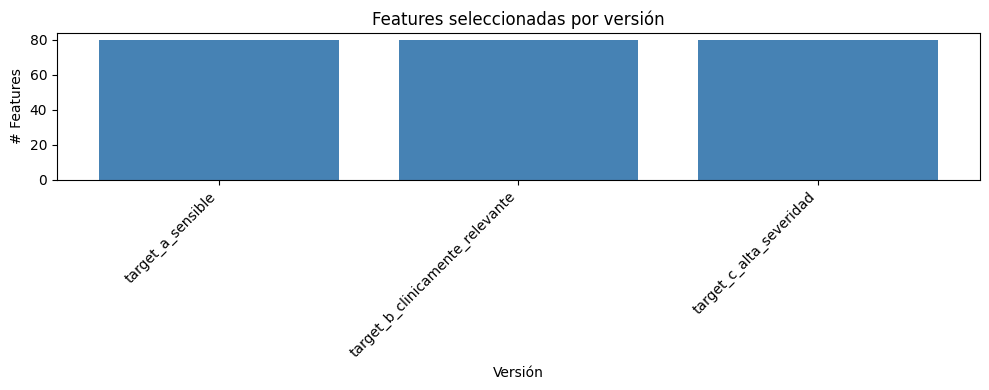

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.bar(df_version_summary["version"], df_version_summary["selected_features"], color="steelblue")
plt.title("Features seleccionadas por versión")
plt.xlabel("Versión")
plt.ylabel("# Features")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [13]:
df_version_summary[["version", "rows", "target_1_pct", "candidate_features", "selected_features"]]

,version,rows,target_1_pct,candidate_features,selected_features
0,target_a_sensible,23387,59.96,233,80
1,target_b_clinicamente_relevante,23387,43.55,233,80
2,target_c_alta_severidad,23387,17.59,233,80


## 12. Selección de Consenso (opcional)

In [14]:
min_versions = max(1, int(np.ceil(len(df_version_summary) * 0.5)))
consensus_features = selection_artifacts["consensus_features"]

print(f"Features de consenso (>= {min_versions} versiones): {len(consensus_features)}")
print(f"Archivo: {selection_artifacts['consensus_path']}")

Features de consenso (>= 2 versiones): 77
Archivo: ../features/versioned/consensus_selected_features_list.txt


## 13. Estado Final

In [15]:
print("=" * 90)
print("PIPELINE DE SELECCIÓN MULTI-VERSIÓN COMPLETADO")
print("=" * 90)
print(f"Versiones procesadas: {len(df_version_summary)}")
print(f"Carpeta de salida: {VERSION_FEATURES_DIR}")
print("\nArchivos clave:")
print("- summary_versions.csv")
print("- exports_registry_versions.csv")
print("- <version>_variable_ranking.csv")
print("- <version>_selected_features_list.txt")
print("- consensus_selected_features_list.txt")

PIPELINE DE SELECCIÓN MULTI-VERSIÓN COMPLETADO
Versiones procesadas: 3
Carpeta de salida: ../features/versioned

Archivos clave:
- summary_versions.csv
- exports_registry_versions.csv
- <version>_variable_ranking.csv
- <version>_selected_features_list.txt
- consensus_selected_features_list.txt
